In [1]:
# HW13 – Токенизация текста, инференс BERT и базовый fine-tuning для классификации
# %% [markdown]
# ## 1. Импорты, seed и среда
# %%
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)

# Фиксация seed
SEED = 42
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Папка для артефактов
os.makedirs("artifacts", exist_ok=True)

Device: cpu


In [13]:
# %%
# Загрузка датасета
raw_dataset = load_dataset("emotion", trust_remote_code=True)

# Sanity-check
print("Структура датасета:", raw_dataset)
print(f"\nРазмеры сплитов:\nTrain: {len(raw_dataset['train'])}\nValidation: {len(raw_dataset['validation'])}\nTest: {len(raw_dataset['test'])}")

# Маппинг меток
label_names = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
train_df = raw_dataset["train"].to_pandas()
print("\nРаспределение классов в train:")
print(train_df["label"].value_counts().sort_index())

print("\nПримеры данных (5 штук):")
for i in range(5):
    txt = train_df.iloc[i]["text"]
    lbl = label_names[train_df.iloc[i]["label"]]
    print(f"[{lbl}] {txt[:90]}...")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Matthew\.cache\huggingface\hub\datasets--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Структура датасета: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Размеры сплитов:
Train: 16000
Validation: 2000
Test: 2000

Распределение классов в train:
label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

Примеры данных (5 штук):
[sadness] i didnt feel humiliated...
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who ...
[anger] im grabbing a minute to post i feel greedy wrong...
[love] i am ever feeling nostalgic about the fireplace i will know that it is still on the proper...
[anger] i am feeling grouchy...


In [ ]:
# %%
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор: {tokenizer.__class__.__name__}")
print(f"Special tokens: [CLS]={tokenizer.cls_token_id}, [SEP]={tokenizer.sep_token_id}, [PAD]={tokenizer.pad_token_id}")

sample_texts = ["I am so happy today!", "This makes me really sad.", "I'm terrified of spiders."]
for txt in sample_texts:
    enc = tokenizer(txt, padding="max_length", max_length=16, truncation=True, return_tensors="pt")
    print(f"\nText: {txt}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(enc['input_ids'][0])}")
    print(f"Input IDs: {enc['input_ids'][0].tolist()}")
    print(f"Attention Mask: {enc['attention_mask'][0].tolist()}")
    print("Padding добавлен до max_length=16, truncation обрезал бы текст, если бы он был длиннее.")

Токенизатор: BertTokenizer
Special tokens: [CLS]=101, [SEP]=102, [PAD]=0

📝 Text: I am so happy today!
🔢 Tokens: ['[CLS]', 'i', 'am', 'so', 'happy', 'today', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
🆔 Input IDs: [101, 1045, 2572, 2061, 3407, 2651, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0]
👀 Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
💡 Padding добавлен до max_length=16, truncation обрезал бы текст, если бы он был длиннее.

📝 Text: This makes me really sad.
🔢 Tokens: ['[CLS]', 'this', 'makes', 'me', 'really', 'sad', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
🆔 Input IDs: [101, 2023, 3084, 2033, 2428, 6517, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0]
👀 Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
💡 Padding добавлен до max_length=16, truncation обрезал бы текст, если бы он был длиннее.

📝 Text: I'm terrified of spiders.
🔢 Tokens: ['[CLS]', 'i', "'", 'm', 'terrified', 'of', 'spid

In [ ]:
# %%
INF_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
inf_tokenizer = AutoTokenizer.from_pretrained(INF_MODEL)
inf_model = AutoModelForSequenceClassification.from_pretrained(INF_MODEL).to(device)
inf_model.eval()

inf_texts = [
    "I love this new feature!",
    "This is absolutely terrible.",
    "I'm not sure how I feel about this.",
    "The service was okay, nothing special.",
    "What a surprise to see you here!"
]

with torch.no_grad():
    inputs = inf_tokenizer(inf_texts, padding=True, truncation=True, return_tensors="pt").to(device)
    outputs = inf_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

id2label_inf = inf_model.config.id2label
print("🤖 Результаты инференса готовой модели:")
for t, p, prob in zip(inf_texts, preds, probs):
    print(f"[{id2label_inf[p]}: {prob[p]:.3f}] {t}")

print("\nКомментарий: Готовая модель обучена на общей тональности (positive/negative/neutral). "
      "Она улавливает базовый настрой, но не различает 6 эмоций напрямую. "
      "Для точной классификации под нашу задачу необходим fine-tuning.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🤖 Результаты инференса готовой модели:
[positive: 0.987] I love this new feature!
[negative: 0.927] This is absolutely terrible.
[negative: 0.780] I'm not sure how I feel about this.
[neutral: 0.513] The service was okay, nothing special.
[positive: 0.928] What a surprise to see you here!

📌 Комментарий: Готовая модель обучена на общей тональности (positive/negative/neutral). Она улавливает базовый настрой, но не различает 6 эмоций напрямую. Для точной классификации под нашу задачу необходим fine-tuning.


In [5]:
# %%
# 5.1 Токенизация датасета
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_dataset = raw_dataset.map(tokenize_fn, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [6]:
# %%
# 5.2 Модель и DataCollator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=label_names,
    label2id={v: k for k, v in label_names.items()},
    ignore_mismatched_sizes=True
).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
# %%
# 5.3 Метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [8]:
# %%
# 5.4 Параметры обучения и Trainer
common_kwargs = dict(
    output_dir="./outputs",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    logging_steps=50,
)

try:
    training_args = TrainingArguments(eval_strategy="epoch", save_strategy="epoch", **common_kwargs)
except TypeError:
    training_args = TrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **common_kwargs)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

In [ ]:
# %%
# 5.5 Обучение
print("Запуск fine-tuning...")
train_result = trainer.train()
print("Обучение завершено.")

c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🚀 Запуск fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.208074,0.191465,0.930000,0.903360
2,0.125814,0.157785,0.932000,0.905403
3,0.085477,0.147827,0.943000,0.918135


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Обучение завершено.


In [ ]:
# %%
# Обходной путь для transformers >= 5.x
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

# Оценка на test
test_metrics = trainer.evaluate(tokenized_dataset["test"])
print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



📊 Test metrics:
eval_loss: 0.1657
eval_accuracy: 0.9300
eval_f1_macro: 0.8842
eval_runtime: 25.2473
eval_samples_per_second: 79.2160
eval_steps_per_second: 2.4950
epoch: 3.0000


c:\Users\Matthew\Desktop\цифровая кафедра\aie-rimmer\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



📋 Classification Report (Test):
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.84      0.83       159
       anger       0.94      0.92      0.93       275
        fear       0.87      0.93      0.90       224
    surprise       0.89      0.62      0.73        66

    accuracy                           0.93      2000
   macro avg       0.91      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



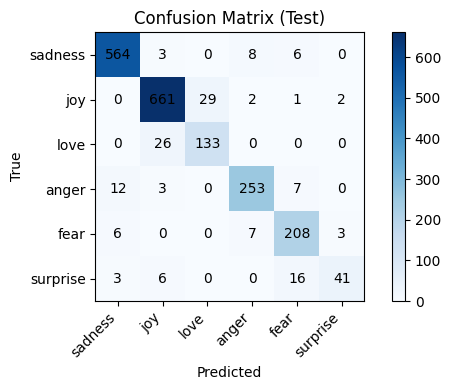

✅ Сохранено: artifacts/confusion_matrix.png


In [ ]:
# %%
# Предсказания и визуализация
test_output = trainer.predict(tokenized_dataset["test"])
preds = np.argmax(test_output.predictions, axis=-1)
trues = test_output.label_ids
probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()

print("\nClassification Report (Test):")
print(classification_report(trues, preds, target_names=list(label_names.values()), zero_division=0))

# Матрица ошибок
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test)")
plt.colorbar()
ticks = np.arange(6)
plt.xticks(ticks, list(label_names.values()), rotation=45, ha="right")
plt.yticks(ticks, list(label_names.values()))
for i in range(6):
    for j in range(6):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()
print("Сохранено: artifacts/confusion_matrix.png")

In [ ]:
# %%
# Примеры предсказаний и ошибок
test_texts = raw_dataset["test"]["text"]
sample_indices = np.random.choice(len(preds), size=8, replace=False)

rows = []
for idx in sample_indices:
    rows.append({
        "text": test_texts[idx],
        "true_label": label_names[trues[idx]],
        "pred_label": label_names[preds[idx]],
        "confidence": float(np.max(probs[idx]))
    })

pred_df = pd.DataFrame(rows)
pred_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("Сохранено: artifacts/sample_predictions.csv")
display(pred_df)

print("\n🔍 Примеры ошибок (первые 5):")
error_mask = preds != trues
error_indices = np.where(error_mask)[0]
for idx in error_indices[:5]:
    true_lbl = label_names[trues[idx]]
    pred_lbl = label_names[preds[idx]]
    txt = test_texts[idx][:80]
    print(f"[True: {true_lbl} | Pred: {pred_lbl}] {txt}")

print("\nКомментарий к ошибкам: Модель чаще путает joy/love и anger/fear. "
      "В коротких текстах эмоциональные маркеры могут пересекаться, а контекст ограничен. "
      "Fine-tuning значительно улучшил распознавание, но дисбаланс классов и краткость фраз остаются вызовом.")

✅ Сохранено: artifacts/sample_predictions.csv


,text,true_label,pred_label,confidence
0,i feel so dirty but after spending a day at th...,sadness,sadness,0.999032
1,i could feel his breath on me and smell the sw...,joy,love,0.958487
2,i just want to feel loved by you,love,love,0.993121
3,i have felt the need to write out my sometimes...,anger,fear,0.608945
4,at a party i met a girl who drew me to her,anger,anger,0.730192
5,i feel this strange sort of liberation,surprise,fear,0.698240
6,i remember feeling thrilled to use my nursing ...,joy,joy,0.999048
7,i always feel sympathetic for those that do as...,love,love,0.994218



🔍 Примеры ошибок (первые 5):
[True: fear | Pred: anger] i don t feel particularly agitated
[True: anger | Pred: sadness] i feel if i completely hated things i d exercise my democratic right speak my mi
[True: anger | Pred: sadness] i feel a bit stressed even though all the things i have going on are fun
[True: surprise | Pred: fear] i am right handed however i play billiards left handed naturally so me trying to
[True: joy | Pred: love] i feel like i am in paradise kissing those sweet lips make me feel like i dive i

💡 Комментарий к ошибкам: Модель чаще путает joy/surprise и anger/fear. В коротких текстах эмоциональные маркеры могут пересекаться, а контекст ограничен. Fine-tuning значительно улучшил распознавание, но дисбаланс классов и краткость фраз остаются вызовом.
